# FAO GMIA v5：灌漑設備ストック変数の作成と品質確認

このノートブックは、FAO GMIA v5だけを使って、既存の5分グリッドに対応した灌漑変数を作成します。

LGRIP30、NASA Earthdata、Google Earth Engineは使用しません。

作成する変数は次の2種類です。

| 変数 | 用途 |
|---|---|
| 設備面積 / セル面積 | 診断用。耕作地量の情報を含み得るため、原則としてモデルには直接投入しない |
| 50 km近傍の設備面積 / 2005年耕作地面積 | モデル投入候補。灌漑設備ストックの近似 |

GMIA v5は「実際にその年に灌漑された面積」ではなく、灌漑設備を備えた面積のデータです。

In [41]:
from __future__ import annotations

import gc
import shutil
from pathlib import Path
from urllib.request import Request, urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

ROOT = Path(r"C:\masterresearch\Comparative_advantage")
GAEZ_DIR = ROOT / "GAEZ"
CROPLAND_DIR = ROOT / "HYDE3.4" / "cropland_npys"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"

OUTPUT_DIR = GAEZ_DIR / "IrrigationData" / "gmia_only"
GMIA_DIR = OUTPUT_DIR / "gmia_v5"
FIGURE_DIR = OUTPUT_DIR / "figures"

for directory in [OUTPUT_DIR, GMIA_DIR, FIGURE_DIR, FEATURE_CACHE]:
    directory.mkdir(parents=True, exist_ok=True)

CELL_DEG = 1.0 / 12.0
NEIGHBORHOOD_RADIUS_KM = 50.0
JAPAN_EXTENT = (122.0, 154.0, 20.0, 47.0)
REBUILD_DERIVED_CACHE = False

print("Output directory:", OUTPUT_DIR)
print("Feature cache:", FEATURE_CACHE)
print("Neighborhood radius (km):", NEIGHBORHOOD_RADIUS_KM)

Output directory: C:\masterresearch\Comparative_advantage\GAEZ\IrrigationData\gmia_only
Feature cache: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\features_cache
Neighborhood radius (km): 50.0


## 1. GMIA v5の取得または既存ファイルの再利用

GMIA v5のZIPが既に保存されていれば再利用します。未取得の場合だけ、FAOの配布URLから取得します。

In [42]:
GMIA_URL = (
    "https://firebasestorage.googleapis.com/v0/b/"
    "fao-aquastat.appspot.com/o/"
    "GIS%2Fgmia_v5_aei_pct_asc.zip"
    "?alt=media&token=e448ce53-296f-4756-90c1-75c87f74e569"
)
GMIA_ZIP = GMIA_DIR / "gmia_v5_aei_pct_asc.zip"

if not GMIA_ZIP.exists():
    print("Downloading FAO GMIA v5...")
    request = Request(GMIA_URL, headers={"User-Agent": "Mozilla/5.0"})
    partial_path = GMIA_ZIP.with_suffix(".zip.part")
    try:
        with urlopen(request, timeout=180) as response:
            with partial_path.open("wb") as output_file:
                shutil.copyfileobj(response, output_file)
        partial_path.replace(GMIA_ZIP)
    finally:
        if partial_path.exists():
            partial_path.unlink()
else:
    print("Already downloaded:", GMIA_ZIP)

asc_files = [
    path for path in GMIA_DIR.rglob("*")
    if path.suffix.lower() == ".asc"
]

if not asc_files:
    with ZipFile(GMIA_ZIP, "r") as archive:
        archive.extractall(GMIA_DIR)
    asc_files = [
        path for path in GMIA_DIR.rglob("*")
        if path.suffix.lower() == ".asc"
    ]

if len(asc_files) != 1:
    raise RuntimeError(
        f"GMIAのASCファイルが1つに特定できません: {asc_files}"
    )

GMIA_ASC = asc_files[0]
print("GMIA grid:", GMIA_ASC)

Already downloaded: C:\masterresearch\Comparative_advantage\GAEZ\IrrigationData\gmia_only\gmia_v5\gmia_v5_aei_pct_asc.zip
GMIA grid: C:\masterresearch\Comparative_advantage\GAEZ\IrrigationData\gmia_only\gmia_v5\gmia_v5_aei_pct.asc


## 2. 既存5分グリッドへの整合

In [43]:
lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
expected_shape = (len(lat), len(lon))

with rasterio.open(GMIA_ASC) as src:
    gmia_raw = src.read(1).astype(np.float32)
    gmia_nodata = src.nodata
    gmia_transform = src.transform
    gmia_crs = src.crs
    source_lon = (
        gmia_transform.c
        + (np.arange(src.width) + 0.5) * gmia_transform.a
    )
    source_lat = (
        gmia_transform.f
        + (np.arange(src.height) + 0.5) * gmia_transform.e
    )

print("GMIA shape:", gmia_raw.shape)
print("Target shape:", expected_shape)
print("GMIA CRS:", gmia_crs)
print("GMIA nodata:", gmia_nodata)

if gmia_raw.shape != expected_shape:
    raise ValueError(
        f"GMIAと既存グリッドのshapeが一致しません: "
        f"{gmia_raw.shape} != {expected_shape}"
    )

if not np.allclose(source_lat, lat, atol=1e-3):
    raise ValueError("GMIAの緯度中心が既存グリッドと一致しません。")

if not np.allclose(source_lon, lon, atol=1e-3):
    raise ValueError("GMIAの経度中心が既存グリッドと一致しません。")

gmia_equipped_pct_of_cell = gmia_raw.copy()

if gmia_nodata is not None:
    gmia_equipped_pct_of_cell[
        gmia_equipped_pct_of_cell == gmia_nodata
    ] = 0.0

gmia_equipped_pct_of_cell[
    ~np.isfinite(gmia_equipped_pct_of_cell)
] = 0.0

gmia_equipped_pct_of_cell = np.clip(
    gmia_equipped_pct_of_cell,
    0.0,
    100.0,
).astype(np.float32)

GMIA_RAW_CACHE = (
    FEATURE_CACHE / "gmia_v5_area_equipped_pct_of_cell_5min.npy"
)
np.save(GMIA_RAW_CACHE, gmia_equipped_pct_of_cell)

print("Saved:", GMIA_RAW_CACHE)
print(
    "GMIA equipped-area percentiles:",
    np.percentile(
        gmia_equipped_pct_of_cell,
        [0, 25, 50, 75, 90, 95, 99, 100],
    ),
)

GMIA shape: (2160, 4320)
Target shape: (2160, 4320)
GMIA CRS: None
GMIA nodata: -9.0
Saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\features_cache\gmia_v5_area_equipped_pct_of_cell_5min.npy
GMIA equipped-area percentiles: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 3.66749302e-02 1.24999734e+01 1.00000000e+02]


## 3. 2005年耕作地を分母とした灌漑設備ストック率

同一セルの比率は、セル内の耕作地が少ない地域で不安定になり得ます。
そこで、設備面積と2005年耕作地面積をそれぞれ50 km近傍で合計してから割ります。

この変数は、耕作地の量そのものではなく、近傍の耕作地に対する灌漑設備ストックの大きさを表すことを狙います。

In [44]:
cropland_cube = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")

if 2005 not in years:
    raise ValueError("HYDE耕作地データに2005年がありません。")

year_2005_index = int(np.where(years == 2005)[0][0])
cropland_2005 = np.asarray(
    cropland_cube[year_2005_index],
    dtype=np.float32,
).copy()
cropland_2005[~np.isfinite(cropland_2005)] = np.nan

if np.nanmax(cropland_2005) > 1.5:
    cropland_2005 /= 100.0

cropland_2005 = np.clip(cropland_2005, 0.0, 1.0)

grid_area_km2 = np.asarray(
    np.load(
        CROPLAND_DIR / "grid_area_km2.npy",
        mmap_mode="r",
    ),
    dtype=np.float32,
)

if grid_area_km2.shape != expected_shape:
    raise ValueError("grid_area_km2のshapeが一致しません。")

gmia_equipped_area_km2 = (
    gmia_equipped_pct_of_cell / 100.0 * grid_area_km2
).astype(np.float32)
cropland_area_2005_km2 = (
    cropland_2005 * grid_area_km2
).astype(np.float32)


def rolling_sum_horizontal(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()

    extended = np.concatenate(
        [
            values[:, -half_width:],
            values,
            values[:, :half_width],
        ],
        axis=1,
    )
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((values.shape[0], 1), dtype=np.float64),
            np.cumsum(extended, axis=1, dtype=np.float64),
        ],
        axis=1,
    )
    return (
        cumulative[:, width:] - cumulative[:, :-width]
    ).astype(np.float32)


def rolling_sum_vertical(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()

    padded = np.pad(
        values,
        ((half_width, half_width), (0, 0)),
        mode="constant",
    )
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((1, values.shape[1]), dtype=np.float64),
            np.cumsum(padded, axis=0, dtype=np.float64),
        ],
        axis=0,
    )
    return (
        cumulative[width:] - cumulative[:-width]
    ).astype(np.float32)


def latitude_aware_box_sum(values, lat_values, lon_values, radius_km):
    values = np.asarray(values, dtype=np.float32)
    earth_radius_km = 6371.0088
    km_per_degree = earth_radius_km * np.pi / 180.0
    lat_step = float(np.median(np.abs(np.diff(lat_values))))
    lon_step = float(np.median(np.abs(np.diff(lon_values))))

    half_lat = max(
        1,
        int(np.ceil(radius_km / (km_per_degree * lat_step))),
    )

    cos_lat = np.clip(
        np.cos(np.deg2rad(lat_values)),
        1e-6,
        None,
    )
    half_lon_by_row = np.ceil(
        radius_km
        / (km_per_degree * cos_lat * lon_step)
    ).astype(np.int32)
    half_lon_by_row = np.minimum(
        half_lon_by_row,
        values.shape[1] // 2 - 1,
    )

    finite_values = np.where(
        np.isfinite(values),
        values,
        0.0,
    ).astype(np.float32)

    horizontal = np.zeros_like(finite_values, dtype=np.float32)

    for half_lon in np.unique(half_lon_by_row):
        selected_rows = np.flatnonzero(
            half_lon_by_row == half_lon
        )
        horizontal[selected_rows] = rolling_sum_horizontal(
            finite_values[selected_rows],
            int(half_lon),
        )

    return rolling_sum_vertical(horizontal, half_lat)


GMIA_TECH_CACHE = (
    FEATURE_CACHE
    / "gmia_v5_equipped_share_of_cropland_2005_wx50km.npy"
)
GMIA_TECH_RAW_CACHE = (
    OUTPUT_DIR
    / "gmia_v5_equipped_share_of_cropland_2005_wx50km_unclipped.npy"
)

# モデル用キャッシュと未クリップ診断用キャッシュの両方が
# 存在するときだけ再利用する。片方だけ残っている場合は再計算する。
cache_pair_is_available = (
    GMIA_TECH_CACHE.exists()
    and GMIA_TECH_RAW_CACHE.exists()
)

if cache_pair_is_available and not REBUILD_DERIVED_CACHE:
    gmia_equipped_share_cropland_50km = np.load(GMIA_TECH_CACHE)
    gmia_equipped_share_cropland_50km_raw = np.load(
        GMIA_TECH_RAW_CACHE
    )
    if (
        gmia_equipped_share_cropland_50km.shape != expected_shape
        or gmia_equipped_share_cropland_50km_raw.shape != expected_shape
    ):
        print("Existing GMIA cache has the wrong shape; recomputing.")
        cache_pair_is_available = False
    else:
        print("Reused existing derived GMIA cache:", GMIA_TECH_CACHE)
elif GMIA_TECH_CACHE.exists() or GMIA_TECH_RAW_CACHE.exists():
    print("Partial GMIA cache detected; recomputing both derived files.")

if not cache_pair_is_available or REBUILD_DERIVED_CACHE:
    equipped_area_50km = latitude_aware_box_sum(
        gmia_equipped_area_km2,
        lat,
        lon,
        NEIGHBORHOOD_RADIUS_KM,
    )
    cropland_area_50km = latitude_aware_box_sum(
        cropland_area_2005_km2,
        lat,
        lon,
        NEIGHBORHOOD_RADIUS_KM,
    )

    gmia_equipped_share_cropland_50km_raw = np.full(
        expected_shape,
        np.nan,
        dtype=np.float32,
    )
    sufficient_denominator = cropland_area_50km >= 5.0
    gmia_equipped_share_cropland_50km_raw[
        sufficient_denominator
    ] = (
        equipped_area_50km[sufficient_denominator]
        / cropland_area_50km[sufficient_denominator]
    )

    gmia_equipped_share_cropland_50km = np.clip(
        gmia_equipped_share_cropland_50km_raw,
        0.0,
        1.0,
    ).astype(np.float32)

    np.save(
        GMIA_TECH_CACHE,
        gmia_equipped_share_cropland_50km,
    )
    np.save(
        GMIA_TECH_RAW_CACHE,
        gmia_equipped_share_cropland_50km_raw,
    )
    print("Created derived GMIA cache:", GMIA_TECH_CACHE)

finite_raw = gmia_equipped_share_cropland_50km_raw[
    np.isfinite(gmia_equipped_share_cropland_50km_raw)
]

print(
    "Derived GMIA percentiles:",
    np.percentile(
        finite_raw,
        [0, 25, 50, 75, 90, 95, 99, 100],
    ),
)
print(
    "Raw share above 1:",
    float(np.mean(finite_raw > 1.0)),
)

Partial GMIA cache detected; recomputing both derived files.
Created derived GMIA cache: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\features_cache\gmia_v5_equipped_share_of_cropland_2005_wx50km.npy
Derived GMIA percentiles: [0.00000000e+00 3.22046294e-03 5.56270927e-02 3.13649252e-01
 7.74090600e-01 1.12955850e+00 2.59284190e+00 2.78764893e+02]
Raw share above 1: 0.06329866527648224


## 4. 分布と基本統計

セル面積分母のGMIAと、2005年耕作地分母の50 km近傍率を比較します。

,variable,unit,n,min,median,mean,p90,p99,max
0,GMIA equipped area / cell area,percent,9331200,0.0,0.000000,0.457307,0.00000,12.49997,100.0
1,50-km equipped area / 2005 cropland area,share,1501959,0.0,0.055627,0.216071,0.77409,1.00000,1.0


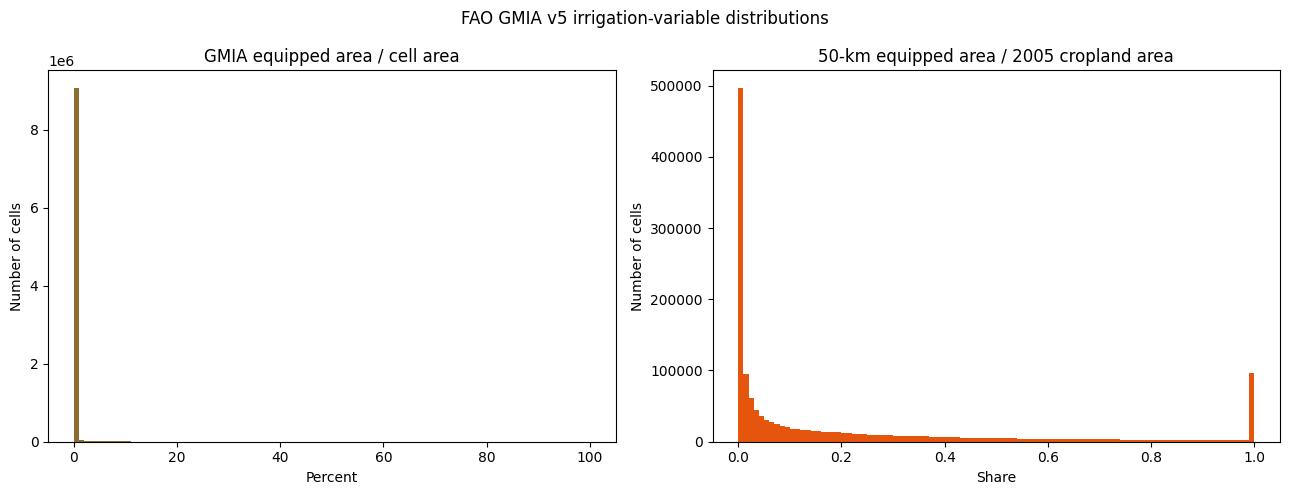

Saved: C:\masterresearch\Comparative_advantage\GAEZ\IrrigationData\gmia_only\figures\gmia_v5_distributions.png


In [45]:
def finite_values(values):
    values = np.asarray(values)
    return values[np.isfinite(values)]


raw_values = finite_values(gmia_equipped_pct_of_cell)
tech_values = finite_values(gmia_equipped_share_cropland_50km)

summary = pd.DataFrame(
    [
        {
            "variable": "GMIA equipped area / cell area",
            "unit": "percent",
            "n": raw_values.size,
            "min": np.min(raw_values),
            "median": np.median(raw_values),
            "mean": np.mean(raw_values),
            "p90": np.percentile(raw_values, 90),
            "p99": np.percentile(raw_values, 99),
            "max": np.max(raw_values),
        },
        {
            "variable": "50-km equipped area / 2005 cropland area",
            "unit": "share",
            "n": tech_values.size,
            "min": np.min(tech_values),
            "median": np.median(tech_values),
            "mean": np.mean(tech_values),
            "p90": np.percentile(tech_values, 90),
            "p99": np.percentile(tech_values, 99),
            "max": np.max(tech_values),
        },
    ]
)

display(summary)
summary.to_csv(
    OUTPUT_DIR / "gmia_v5_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(raw_values, bins=100, color="#8c6d31")
axes[0].set_title("GMIA equipped area / cell area")
axes[0].set_xlabel("Percent")
axes[0].set_ylabel("Number of cells")

axes[1].hist(tech_values, bins=100, color="#e6550d")
axes[1].set_title("50-km equipped area / 2005 cropland area")
axes[1].set_xlabel("Share")
axes[1].set_ylabel("Number of cells")

fig.suptitle("FAO GMIA v5 irrigation-variable distributions")
fig.tight_layout()
distribution_path = FIGURE_DIR / "gmia_v5_distributions.png"
fig.savefig(distribution_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", distribution_path)

## 5. 全球図と日本周辺図

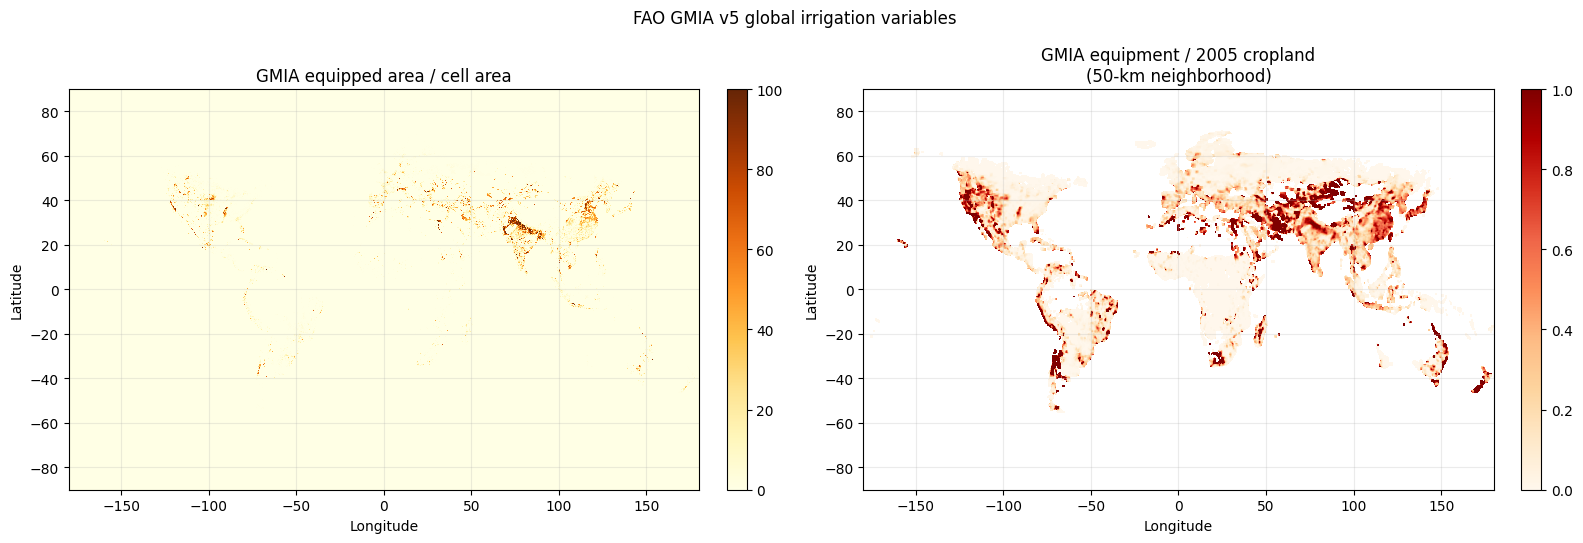

Saved: C:\masterresearch\Comparative_advantage\GAEZ\IrrigationData\gmia_only\figures\gmia_v5_global_maps.png


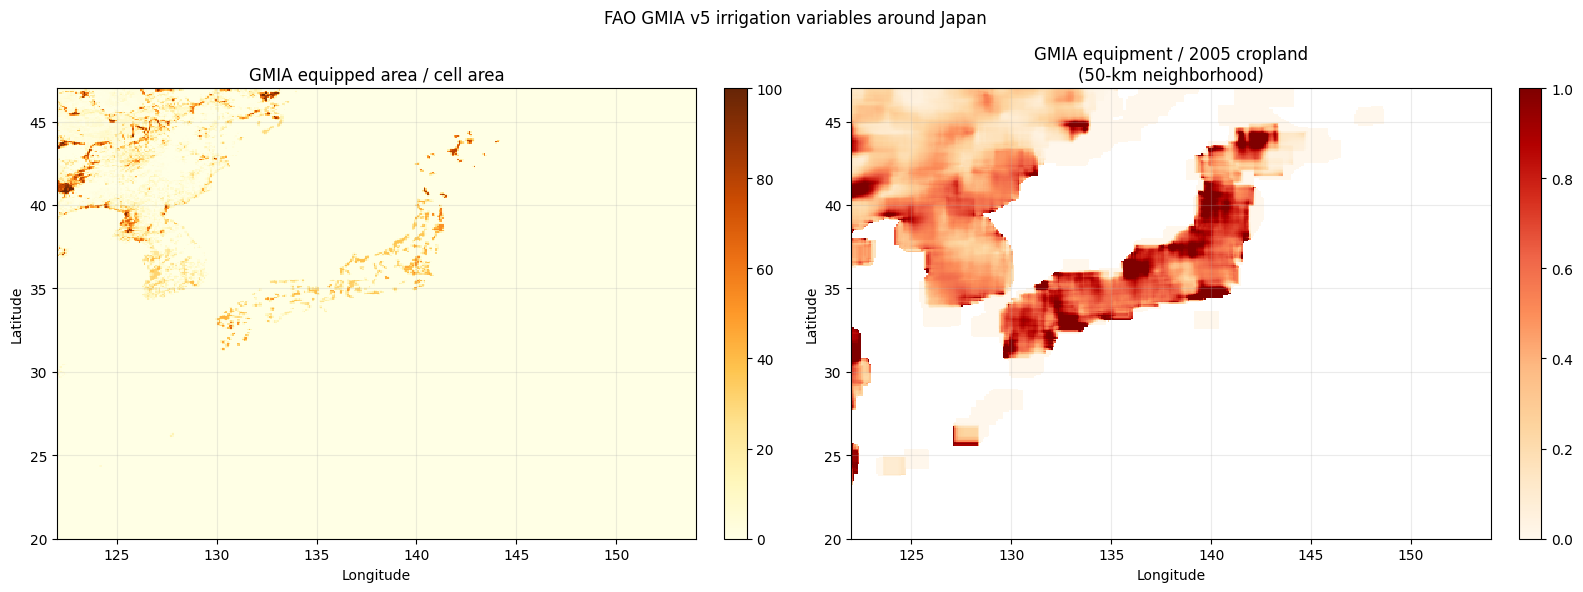

Saved: C:\masterresearch\Comparative_advantage\GAEZ\IrrigationData\gmia_only\figures\gmia_v5_japan_maps.png


In [46]:
def plot_grid(ax, values, title, cmap, vmin=None, vmax=None, extent=None):
    image = np.ma.masked_invalid(np.asarray(values, dtype=np.float32))
    if extent is None:
        extent = (
            float(lon.min() - CELL_DEG / 2.0),
            float(lon.max() + CELL_DEG / 2.0),
            float(lat.min() - CELL_DEG / 2.0),
            float(lat.max() + CELL_DEG / 2.0),
        )

    im = ax.imshow(
        image,
        origin="upper" if lat[0] > lat[-1] else "lower",
        extent=extent,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        aspect="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.25)
    return im


full_extent = (
    float(lon.min() - CELL_DEG / 2.0),
    float(lon.max() + CELL_DEG / 2.0),
    float(lat.min() - CELL_DEG / 2.0),
    float(lat.max() + CELL_DEG / 2.0),
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
im0 = plot_grid(
    axes[0],
    gmia_equipped_pct_of_cell,
    "GMIA equipped area / cell area",
    "YlOrBr",
    vmin=0,
    vmax=100,
    extent=full_extent,
)
im1 = plot_grid(
    axes[1],
    gmia_equipped_share_cropland_50km,
    "GMIA equipment / 2005 cropland\n(50-km neighborhood)",
    "OrRd",
    vmin=0,
    vmax=1,
    extent=full_extent,
)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.suptitle("FAO GMIA v5 global irrigation variables")
fig.tight_layout()
global_map_path = FIGURE_DIR / "gmia_v5_global_maps.png"
fig.savefig(global_map_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", global_map_path)


lon_mask = (lon >= JAPAN_EXTENT[0]) & (lon <= JAPAN_EXTENT[1])
lat_mask = (lat >= JAPAN_EXTENT[2]) & (lat <= JAPAN_EXTENT[3])

japan_extent = (
    JAPAN_EXTENT[0],
    JAPAN_EXTENT[1],
    JAPAN_EXTENT[2],
    JAPAN_EXTENT[3],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = plot_grid(
    axes[0],
    gmia_equipped_pct_of_cell[np.ix_(lat_mask, lon_mask)],
    "GMIA equipped area / cell area",
    "YlOrBr",
    vmin=0,
    vmax=100,
    extent=japan_extent,
)
im1 = plot_grid(
    axes[1],
    gmia_equipped_share_cropland_50km[np.ix_(lat_mask, lon_mask)],
    "GMIA equipment / 2005 cropland\n(50-km neighborhood)",
    "OrRd",
    vmin=0,
    vmax=1,
    extent=japan_extent,
)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.suptitle("FAO GMIA v5 irrigation variables around Japan")
fig.tight_layout()
japan_map_path = FIGURE_DIR / "gmia_v5_japan_maps.png"
fig.savefig(japan_map_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", japan_map_path)

## 6. モデル投入用ファイルと利用メモ

モデル投入候補は、次のファイルです。

`gmia_v5_equipped_share_of_cropland_2005_wx50km.npy`

これは、50 km近傍のGMIA設備面積を、50 km近傍の2005年耕作地面積で割ったものです。
`gmia_v5_area_equipped_pct_of_cell_5min.npy`は診断用として保存します。

GMIAをモデルへ追加する場合は、まずbaselineと`+ GMIA`を別々に学習し、R²・誤差空間分布・統合SHAPを比較します。

In [47]:
feature_manifest = pd.DataFrame(
    [
        {
            "feature_name": "gmia_v5_equipped_share_of_cropland_2005_wx50km",
            "path": str(GMIA_TECH_CACHE),
            "year": 2005,
            "source": "FAO GMIA v5",
            "definition": "50-km equipped area / 50-km 2005 cropland area",
            "role": "model candidate",
        },
        {
            "feature_name": "gmia_v5_area_equipped_pct_of_cell_5min",
            "path": str(GMIA_RAW_CACHE),
            "year": 2005,
            "source": "FAO GMIA v5",
            "definition": "equipped area / grid-cell area",
            "role": "diagnostic only",
        },
    ]
)

manifest_path = OUTPUT_DIR / "gmia_v5_feature_manifest.csv"
feature_manifest.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8-sig",
)

print(feature_manifest)
print("Saved:", manifest_path)
print("GMIA-only preparation completed.")

                                     feature_name  \
0  gmia_v5_equipped_share_of_cropland_2005_wx50km   
1          gmia_v5_area_equipped_pct_of_cell_5min   

                                                path  year       source  \
0  C:\masterresearch\Comparative_advantage\GAEZ\C...  2005  FAO GMIA v5   
1  C:\masterresearch\Comparative_advantage\GAEZ\C...  2005  FAO GMIA v5   

                                       definition             role  
0  50-km equipped area / 50-km 2005 cropland area  model candidate  
1                  equipped area / grid-cell area  diagnostic only  
Saved: C:\masterresearch\Comparative_advantage\GAEZ\IrrigationData\gmia_only\gmia_v5_feature_manifest.csv
GMIA-only preparation completed.
